# 🚀 Handwriting Recognition: Encoder-Decoder (TrOCR-style)

## 📋 Lessons Learned from CTC Failures:

### ❌ **Why CTC Failed:**
1. **CTC Loss collapse**: Model learns to output blank tokens
   - Loss decreases (17.99 → 0.63) but CER stuck at 98.6%
   - Predictions mostly empty: "", "h", "wh"
   - CTC rewards blank → greedy decode removes them

2. **Monotonic alignment assumption**: CTC assumes strict left-to-right
   - Handwriting has variations, skips, ligatures
   - Hard for CTC to model flexible alignments

3. **No language modeling**: CTC only sees char sequences
   - Can't leverage context ("teh" → "the")
   - Encoder-Decoder with attention learns dependencies

### ✅ **Why Encoder-Decoder Works Better:**
1. **Attention mechanism**: Model learns WHERE to look
   - Can attend to any part of image (not just left-to-right)
   - Handles cursive, overlapping chars, ligatures

2. **Autoregressive decoding**: Uses previous predictions
   - Language modeling built-in
   - Can correct mistakes using context

3. **SOTA accuracy**: TrOCR achieves WER 5-8% vs CTC 10-15%
   - Proven on handwriting benchmarks
   - Used in production systems

## 🎯 Target:
- **CER < 8%** (beat baseline)
- Stable training (no collapse)
- Meaningful predictions from epoch 5+

## 📦 1. Imports & Config

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import cv2
import numpy as np
import string
import random
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math

# Set seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   Memory: {gpu_memory_gb:.2f} GB")
    if gpu_memory_gb < 15:
        print(f"   ⚠️  WARNING: GPU has <15GB VRAM, may OOM with 6+4 architecture!")
        print(f"   💡 Solution: Reduce BATCH_SIZE to 32 or use gradient accumulation")

# ============================================================
# 🔧 CONFIG (Optimized for Kaggle P100 with 6+4 architecture)
# ============================================================
print(f"\n{'='*60}")
print("⚙️  CONFIG: LARGE MODEL (6+4, d=384)")
print('='*60)
print("   Architecture: MATCHED với checkpoint best_encoder2.pth")
print("   Model size: ~35M params (2.3x baseline)")
print("   Memory: ~4GB VRAM (P100/V100 recommended)")
print("   Training: ~15min/epoch, 40 epochs = ~10 hours")
print('='*60 + '\n')
IMG_H = 64
IMG_W = 256
BATCH_SIZE = 48  # REDUCED from 64 (larger model needs more memory)
EPOCHS = 40  # REDUCED from 50 (prevent overfitting with larger model)
USE_AMP = True

# Training (Fine-tuning with pre-trained checkpoint)
LR = 5e-5  # REDUCED from 1e-4 (fine-tuning with larger pre-trained model)
WARMUP_EPOCHS = 3
GRAD_CLIP_NORM = 10.0  # Increased for larger model
EARLY_STOP_PATIENCE = 20  # More patience for larger model

# Model architecture (MATCHED với checkpoint best_encoder2.pth - 6+4, d=384)
D_MODEL = 384  # Increased from 256 (match checkpoint)
ENC_LAYERS = 6  # Increased from 4 (match checkpoint)
DEC_LAYERS = 4  # Increased from 3 (match checkpoint)
NHEAD = 8
FFN_DIM = 1536  # Increased from 1024 (384 * 4, maintain ratio)
DROPOUT = 0.2  # Increased from 0.1 (prevent overfitting with larger model)

# Special tokens
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'

print(f"\n✅ Config (MATCHED với checkpoint 6+4):")
print(f"   Image: {IMG_H}x{IMG_W}")
print(f"   Batch: {BATCH_SIZE}, Epochs: {EPOCHS}")
print(f"   Model: d_model={D_MODEL}, enc={ENC_LAYERS}, dec={DEC_LAYERS}")
print(f"   LR: {LR:.2e}, Warmup: {WARMUP_EPOCHS} epochs")
print(f"   ⚠️ Larger model: ~35M params, ~4GB VRAM, ~15min/epoch")
print('='*60)

🔥 Device: cuda
   GPU: Tesla P100-PCIE-16GB
   Memory: 17.06 GB

⚙️  CONFIG: LARGE MODEL (6+4, d=384)
   Architecture: MATCHED với checkpoint best_encoder2.pth
   Model size: ~35M params (2.3x baseline)
   Memory: ~4GB VRAM (P100/V100 recommended)
   Training: ~15min/epoch, 40 epochs = ~10 hours


✅ Config (MATCHED với checkpoint 6+4):
   Image: 64x256
   Batch: 48, Epochs: 40
   Model: d_model=384, enc=6, dec=4
   LR: 5.00e-05, Warmup: 3 epochs
   ⚠️ Larger model: ~35M params, ~4GB VRAM, ~15min/epoch


## 🏗️ 2. Model Architecture

In [30]:
def levenshtein_distance(s1, s2):
    """Calculate edit distance between two strings"""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    
    return previous_row[-1]  # Return int, not ratio!


class PositionalEncoding2D(nn.Module):
    """2D Positional Encoding for image features (MATCHED với MJSynth)"""
    def __init__(self, d_model, max_h=100, max_w=500):
        super().__init__()
        pe = torch.zeros(max_h, max_w, d_model)
        
        # Separate encoding for height and width
        d_model_half = d_model // 2
        div_term = torch.exp(torch.arange(0, d_model_half, 2).float() * 
                            -(math.log(10000.0) / d_model_half))
        
        pos_h = torch.arange(0, max_h).unsqueeze(1)
        pos_w = torch.arange(0, max_w).unsqueeze(1)
        
        pe[:, :, 0:d_model_half:2] = torch.sin(pos_h * div_term).unsqueeze(1).repeat(1, max_w, 1)
        pe[:, :, 1:d_model_half:2] = torch.cos(pos_h * div_term).unsqueeze(1).repeat(1, max_w, 1)
        pe[:, :, d_model_half::2] = torch.sin(pos_w * div_term).unsqueeze(0).repeat(max_h, 1, 1)
        pe[:, :, d_model_half+1::2] = torch.cos(pos_w * div_term).unsqueeze(0).repeat(max_h, 1, 1)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x, h, w):
        # x: [B, seq_len, d_model] where seq_len = h*w
        pe_flat = self.pe[:h, :w].reshape(-1, self.pe.size(-1))  # [h*w, d_model]
        return x + pe_flat.unsqueeze(0)


class PositionalEncoding1D(nn.Module):
    """1D positional encoding for decoder (sequence position)"""
    def __init__(self, d_model, max_len=200):  # INCREASED: IAM has longer words (up to 30+ chars)
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]
    
    def forward(self, x):
        # x: [B, seq_len, d_model]
        return x + self.pe[:, :x.size(1), :]


class ResBlock(nn.Module):
    """ResNet-style residual block"""
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)


class ResNetBackbone(nn.Module):
    """Lightweight ResNet-style CNN backbone (MATCHED với MJSynth checkpoint)"""
    def __init__(self, d_model=384):
        super().__init__()
        # Initial conv
        self.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, 2, 1)
        
        # ResNet blocks
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, d_model, 2, stride=1)
        
    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = []
        # Downsample if needed
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
        layers.append(ResBlock(in_channels, out_channels, stride, downsample))
        for _ in range(1, blocks):
            layers.append(ResBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # x: [B, 1, 64, 256]
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))  # [B, 64, 16, 64]
        x = self.layer1(x)  # [B, 64, 16, 64]
        x = self.layer2(x)  # [B, 128, 8, 32]
        x = self.layer3(x)  # [B, 256, 4, 16]
        x = self.layer4(x)  # [B, d_model, 4, 16]
        return x


class EncoderDecoderHTR(nn.Module):
    """Transformer Encoder-Decoder for Handwriting Recognition"""
    def __init__(self, vocab_size, d_model=256, enc_layers=4, dec_layers=3,
                 nhead=8, ffn_dim=1024, dropout=0.1, max_seq_len=50):
        super().__init__()
        self.d_model = d_model
        self.max_seq_len = max_seq_len
        
        # CNN backbone (MATCHED với MJSynth: ResNet-style)
        self.backbone = ResNetBackbone(d_model)
        
        # Positional encodings (MATCHED tên với MJSynth)
        self.pos_enc_2d = PositionalEncoding2D(d_model)
        self.tgt_pos_enc = PositionalEncoding1D(d_model, max_len=max_seq_len)
        
        # Token embedding for decoder (MATCHED tên với MJSynth: tgt_embed)
        self.tgt_embed = nn.Embedding(vocab_size, d_model)
        
        # Transformer Encoder (processes image features)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True  # Pre-LN for stability
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=enc_layers)
        
        # Transformer Decoder (generates text autoregressively)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=dec_layers)
        
        # Output projection (MATCHED tên với MJSynth: out_proj)
        self.out_proj = nn.Linear(d_model, vocab_size)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Better initialization (TrOCR-style)"""
        # Linear layers: truncated normal
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.trunc_normal_(m.weight, std=0.02)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    
    def encode(self, images):
        """Encode image to features"""
        # CNN: [B, 1, H, W] → [B, C, h, w]
        features = self.backbone(images)
        
        # Flatten: [B, C, h, w] → [B, h*w, C]
        B, C, h, w = features.shape
        features = features.flatten(2).transpose(1, 2)
        
        # Add 2D positional encoding (MATCHED với MJSynth: pass h, w)
        features = self.pos_enc_2d(features, h, w)
        
        # Transformer encoder
        memory = self.encoder(features)
        return memory
    
    def decode(self, tgt_tokens, memory, tgt_mask=None, tgt_key_padding_mask=None):
        """Decode text from memory"""
        # Embed tokens: [B, seq_len] → [B, seq_len, d_model]
        tgt_emb = self.tgt_embed(tgt_tokens) * math.sqrt(self.d_model)
        
        # Add 1D positional encoding
        tgt_emb = self.tgt_pos_enc(tgt_emb)
        
        # Transformer decoder (with cross-attention to encoder memory)
        output = self.decoder(
            tgt_emb,
            memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )
        
        # Project to vocabulary
        logits = self.out_proj(output)
        return logits
    
    def forward(self, images, tgt_tokens, tgt_mask=None, tgt_key_padding_mask=None):
        """Full forward pass (teacher forcing)"""
        memory = self.encode(images)
        logits = self.decode(tgt_tokens, memory, tgt_mask, tgt_key_padding_mask)
        return logits
    
    def generate(self, images, sos_idx, eos_idx, max_len=50):
        """Greedy decoding (inference) - FIXED: per-sample EOS tracking"""
        self.eval()
        with torch.no_grad():
            memory = self.encode(images)
            B = images.size(0)
            
            # Start with <SOS>
            tgt_tokens = torch.full((B, 1), sos_idx, dtype=torch.long, device=images.device)
            finished = torch.zeros(B, dtype=torch.bool, device=images.device)
            
            for _ in range(max_len):
                # Generate causal mask
                tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_tokens.size(1)).to(images.device)
                
                # Decode
                logits = self.decode(tgt_tokens, memory, tgt_mask=tgt_mask)
                
                # Get next token (greedy)
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                
                # Mark finished sequences (found EOS)
                finished = finished | (next_token.squeeze(1) == eos_idx)
                
                # Append to sequence (replace with PAD if already finished)
                next_token_masked = next_token.clone()
                next_token_masked[finished] = sos_idx  # Use SOS as dummy (will be ignored in decode)
                tgt_tokens = torch.cat([tgt_tokens, next_token_masked], dim=1)
                
                # Stop if all sequences finished
                if finished.all():
                    break
            
            return tgt_tokens


print('='*60)
print('✅ Model architecture defined (MATCHED MJSynth checkpoint 6+4)')
print('   Backbone: ResNet-style CNN (MATCHED MJSynth)')
print('   Encoder: Transformer Encoder (6 layers)')
print('   Decoder: Transformer Decoder (4 layers) with cross-attention')
print('   d_model: 384 (from 256), FFN: 1536 (from 1024)')
print('   Parameters: ~35M (from ~15M)')
print('   Output: Autoregressive generation with <SOS>/<EOS>')
print('='*60)

✅ Model architecture defined (MATCHED MJSynth checkpoint 6+4)
   Backbone: ResNet-style CNN (MATCHED MJSynth)
   Encoder: Transformer Encoder (6 layers)
   Decoder: Transformer Decoder (4 layers) with cross-attention
   d_model: 384 (from 256), FFN: 1536 (from 1024)
   Parameters: ~35M (from ~15M)
   Output: Autoregressive generation with <SOS>/<EOS>


## 📊 3. Dataset (IAM Words)

In [31]:
print('='*60)
print('📂 LOADING IAM WORDS DATASET')
print('='*60)

# ============================================================
# Dataset paths (Kaggle or Local)
# ============================================================
# Kaggle paths
IAM_ROOT = '/kaggle/input/iam-handwriting-word-database'
WORDS_FILE_ROOT = '/kaggle/input/iam-handwriting-word-database4'
words_txt = os.path.join(WORDS_FILE_ROOT, 'iam_words', 'words.txt')

# Local paths (uncomment if running locally)
# IAM_ROOT = r'D:\IAM'
# WORDS_FILE_ROOT = r'D:\IAM\iam_words'
# words_txt = os.path.join(WORDS_FILE_ROOT, 'words.txt')

def parse_iam_words(words_txt, root_dir):
    all_samples = []
    skipped = {'status': 0, 'chars': 0, 'missing': 0, 'other': 0}
    
    with open(words_txt, 'r', encoding='utf-8') as f:
        lines = [line for line in f if line.strip() and not line.startswith('#')]
        
        for line in tqdm(lines, desc='Parsing IAM'):
            parts = line.split()
            if len(parts) < 9:
                skipped['other'] += 1
                continue
            
            word_id, status, text = parts[0], parts[1], parts[-1].lower()
            if status != 'ok':
                skipped['status'] += 1
                continue
            if '#' in text or '&' in text or not all(c.isalnum() or c.isspace() for c in text):
                skipped['chars'] += 1
                continue
            
            parts_id = word_id.split('-')
            if len(parts_id) < 2:
                skipped['other'] += 1
                continue
            
            folder1 = parts_id[0]
            folder2 = '-'.join(parts_id[:2])
            img_path = os.path.join(root_dir, 'iam_words', 'words', folder1, folder2, f'{word_id}.png')
            
            if not os.path.exists(img_path):
                skipped['missing'] += 1
                continue
            
            all_samples.append((img_path, text))
    
    print(f'\n✅ Loaded: {len(all_samples):,}')
    print(f'   Skipped: {sum(skipped.values()):,}')
    return all_samples

# Load all samples
all_samples = parse_iam_words(words_txt, IAM_ROOT)
max_label_len = max(len(label) for _, label in all_samples)

print(f'   Max label length: {max_label_len}')

# Random split 90/10 (same as CTC version)
all_images = [p for p, l in all_samples]
all_labels = [l for p, l in all_samples]

train_images, val_images, train_labels, val_labels = train_test_split(
    all_images, all_labels, test_size=0.1, random_state=42
)

print(f'\n📊 Split:')
print(f'   Train: {len(train_images):,} samples')
print(f'   Val:   {len(val_images):,} samples')
print('='*60)

📂 LOADING IAM WORDS DATASET


Parsing IAM: 100%|██████████| 115315/115315 [04:29<00:00, 427.68it/s] 



✅ Loaded: 82,733
   Skipped: 32,582
   Max label length: 17

📊 Split:
   Train: 74,459 samples
   Val:   8,274 samples


## 🔤 4. Vocabulary & DataLoader

In [32]:
# Build vocabulary (MATCHED với MJSynth: NO SPACE)
chars = list(string.ascii_lowercase + string.digits)  # a-z + 0-9 (36 chars, NO SPACE)
vocab = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + chars  # 3 special + 36 chars = 39 total

char_to_idx = {c: i for i, c in enumerate(vocab)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

PAD_IDX = char_to_idx[PAD_TOKEN]
SOS_IDX = char_to_idx[SOS_TOKEN]
EOS_IDX = char_to_idx[EOS_TOKEN]

# Check for space in labels (will be skipped during parsing)
labels_with_space = sum(' ' in l for l in all_labels)
print(f"📚 Vocabulary: {len(vocab)} tokens (MATCHED với MJSynth - NO SPACE)")
print(f"   PAD: {PAD_IDX}, SOS: {SOS_IDX}, EOS: {EOS_IDX}")
print(f"   Chars: {chars[:10]}...")
if labels_with_space > 0:
    print(f"   ⚠️  Note: {labels_with_space}/{len(all_labels)} labels có space (sẽ bị filter)")


def strong_handwriting_augmentation(img):
    """Apply MODERATE augmentation for handwriting (FIXED: reduced prob to avoid over-augmentation)"""
    h, w = img.shape
    
    # 1. Random rotation (-3 to +3 degrees)
    if random.random() < 0.3:  # REDUCED from 0.5
        angle = random.uniform(-3, 3)
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h), borderValue=255)
    
    # 2. Random shear
    if random.random() < 0.3:  # REDUCED from 0.5
        shear = random.uniform(-0.1, 0.1)
        M = np.array([[1, shear, 0], [0, 1, 0]], dtype=np.float32)
        img = cv2.warpAffine(img, M, (w, h), borderValue=255)
    
    # 3. Random scale (0.9x to 1.1x)
    if random.random() < 0.3:  # REDUCED from 0.5
        scale = random.uniform(0.9, 1.1)
        new_h, new_w = int(h * scale), int(w * scale)
        img = cv2.resize(img, (new_w, new_h))
        # Pad or crop back to original size
        if new_h < h or new_w < w:
            canvas = np.ones((h, w), dtype=np.uint8) * 255
            y_offset = (h - new_h) // 2
            x_offset = (w - new_w) // 2
            canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img
            img = canvas
        else:
            y_start = (new_h - h) // 2
            x_start = (new_w - w) // 2
            img = img[y_start:y_start+h, x_start:x_start+w]
    
    # 4. Random Gaussian blur
    if random.random() < 0.3:
        kernel_size = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
    
    # 5. Random noise
    if random.random() < 0.3:
        noise = np.random.normal(0, 5, img.shape).astype(np.float32)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    
    # 6. Random brightness
    if random.random() < 0.3:  # REDUCED from 0.5
        factor = random.uniform(0.8, 1.2)
        img = np.clip(img * factor, 0, 255).astype(np.uint8)
    
    # 7. Random contrast
    if random.random() < 0.3:  # REDUCED from 0.5
        factor = random.uniform(0.8, 1.2)
        mean = img.mean()
        img = np.clip((img - mean) * factor + mean, 0, 255).astype(np.uint8)
    
    return img


class IAMDataset(Dataset):
    def __init__(self, image_paths, labels, char_to_idx, augment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.char_to_idx = char_to_idx
        self.augment = augment
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load image
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.ones((IMG_H, IMG_W), dtype=np.uint8) * 255
        
        # Resize
        img = cv2.resize(img, (IMG_W, IMG_H))
        
        # Augment
        if self.augment:
            img = strong_handwriting_augmentation(img)
        
        # Normalize: [0, 255] → [0, 1]
        img = img.astype(np.float32) / 255.0
        img = torch.FloatTensor(img).unsqueeze(0)  # [1, H, W]
        
        # Encode label: "hello" → [SOS, h, e, l, l, o, EOS]
        label = self.labels[idx]
        label_indices = [SOS_IDX] + [self.char_to_idx.get(c, PAD_IDX) for c in label] + [EOS_IDX]
        label_tensor = torch.LongTensor(label_indices)
        
        return img, label_tensor


def collate_fn(batch):
    """Collate function with padding"""
    images, labels = zip(*batch)
    
    # Stack images
    images = torch.stack(images, dim=0)
    
    # Pad labels to same length
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=PAD_IDX)
    
    return images, labels_padded


train_dataset = IAMDataset(train_images, train_labels, char_to_idx, augment=True)
val_dataset = IAMDataset(val_images, val_labels, char_to_idx, augment=False)

# Optimized for Kaggle: num_workers=4 (Kaggle has 4 CPUs), pin_memory=True, persistent_workers=True
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=4, collate_fn=collate_fn, 
                          pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, collate_fn=collate_fn,
                        pin_memory=True, persistent_workers=True)

print(f"\n✅ DataLoaders created")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print('='*60)

📚 Vocabulary: 39 tokens (MATCHED với MJSynth - NO SPACE)
   PAD: 0, SOS: 1, EOS: 2
   Chars: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']...

✅ DataLoaders created
   Train batches: 1552
   Val batches:   173


## 🔧 5. Training Setup

In [33]:
print('='*60)
print('🔥 CREATE ENCODER-DECODER MODEL')
print('='*60)

model = EncoderDecoderHTR(
    vocab_size=len(vocab),
    d_model=D_MODEL,
    enc_layers=ENC_LAYERS,
    dec_layers=DEC_LAYERS,
    nhead=NHEAD,
    ffn_dim=FFN_DIM,
    dropout=DROPOUT,
    max_seq_len=60  # FIXED: Use absolute value 60 (safe for max_len=50 generation + buffer)
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
params_per_sample = total_params / len(train_dataset)

print(f"✅ Model created (6+4 architecture)")
print(f"   Total params: {total_params/1e6:.2f}M")
print(f"   Params/sample: {params_per_sample:.1f}")
print(f"   Vocab size: {len(vocab)} (3 special + 36 chars)")
print(f"\n📊 Comparison:")
print(f"   CTC model (failed): 6M params, CER stuck at 98.6%")
print(f"   4+3 baseline: ~15M params, CER 7.6% (from scratch)")
print(f"   MJSynth checkpoint (6+4): CER 0.76% on MJSynth")
print(f"   This model (6+4): {total_params/1e6:.1f}M params, Expected CER 6.0-6.3% (transfer learning)")
print(f"   💡 Architecture MATCHED: ResNet backbone + seq2seq decoder")

# ============================================================
# 🔥 LOAD PRE-TRAINED WEIGHTS FROM MJSYNTH (6+4, d=384)
# ============================================================
USE_PRETRAINED = True  # ✅ ENABLED: Architecture now matches (ResNet + seq2seq)

if USE_PRETRAINED:
    # Path to pre-trained weights (Kaggle Dataset)
    # Checkpoint: best_seq2seq_64.pth (6 enc + 4 dec, d_model=384)
    # ✅ UPDATED: User provided dataset path
    pretrained_path = '/kaggle/input/model-mjsynth2/best_seq2seq_64.pth'  # User's MJSynth checkpoint
    
    if os.path.exists(pretrained_path):
        print(f"\n{'='*60}")
        print("🔥 LOADING PRE-TRAINED WEIGHTS FROM MJSYNTH (6+4)")
        print('='*60)
        print(f"   Architecture: 6 encoder + 4 decoder layers, d_model=384")
        print(f"   Checkpoint: best_encoder2.pth (trained on MJSynth)")
        print('='*60)
        print('='*60)
        
        checkpoint = torch.load(pretrained_path, map_location=DEVICE)
        
        # Extract config from checkpoint OR infer from model structure
        config = checkpoint.get('config', {})
        
        # Get state_dict (handle multiple checkpoint formats)
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        elif 'model' in checkpoint:
            # Lightning/custom format: {'model': state_dict, 'optimizer': ...}
            state_dict = checkpoint['model']
        else:
            # Checkpoint IS the state_dict (direct format)
            state_dict = checkpoint
        
        # If config not saved, try to infer from state_dict shapes
        if not config:
            print(f"   🔍 Config not found, inferring from state_dict...")
            print(f"   📋 Sample keys (first 10): {list(state_dict.keys())[:10]}")
            
            # Infer d_model from embedding weight shape (try multiple possible key names)
            embedding_keys = ['token_embedding.weight', 'model.token_embedding.weight', 
                            'module.token_embedding.weight', 'embedding.weight']
            for key in embedding_keys:
                if key in state_dict:
                    config['d_model'] = state_dict[key].shape[1]
                    config['vocab_size'] = state_dict[key].shape[0]
                    print(f"   ✅ Found {key}: d_model={config['d_model']}, vocab={config['vocab_size']}")
                    break
            
            # Infer encoder layers by counting unique layer indices
            enc_layers = set()
            enc_patterns = ['encoder.layers.', 'model.encoder.layers.', 'module.encoder.layers.']
            for k in state_dict.keys():
                for pattern in enc_patterns:
                    if pattern in k:
                        # Extract layer index: 'encoder.layers.0.xxx' -> 0
                        parts = k.split('.')
                        layer_word_idx = parts.index('layers') if 'layers' in parts else -1
                        if layer_word_idx >= 0 and layer_word_idx + 1 < len(parts):
                            try:
                                layer_idx = int(parts[layer_word_idx + 1])
                                enc_layers.add(layer_idx)
                            except ValueError:
                                pass
                        break
            if enc_layers:
                config['enc_layers'] = len(enc_layers)
                print(f"   ✅ Found encoder layers: {sorted(enc_layers)} → {len(enc_layers)} layers")
            
            # Infer decoder layers by counting unique layer indices
            dec_layers = set()
            dec_patterns = ['decoder.layers.', 'model.decoder.layers.', 'module.decoder.layers.']
            for k in state_dict.keys():
                for pattern in dec_patterns:
                    if pattern in k:
                        # Extract layer index: 'decoder.layers.0.xxx' -> 0
                        parts = k.split('.')
                        layer_word_idx = parts.index('layers') if 'layers' in parts else -1
                        if layer_word_idx >= 0 and layer_word_idx + 1 < len(parts):
                            try:
                                layer_idx = int(parts[layer_word_idx + 1])
                                dec_layers.add(layer_idx)
                            except ValueError:
                                pass
                        break
            if dec_layers:
                config['dec_layers'] = len(dec_layers)
                print(f"   ✅ Found decoder layers: {sorted(dec_layers)} → {len(dec_layers)} layers")
        
        # Verify compatibility
        compat_d_model = config.get('d_model') == D_MODEL
        compat_enc = config.get('enc_layers') == ENC_LAYERS
        compat_dec = config.get('dec_layers') == DEC_LAYERS
        compat_vocab = config.get('vocab_size') == len(vocab)
        
        print(f"\n📊 Compatibility Check:")
        print(f"   d_model:    {config.get('d_model')} == {D_MODEL}? {'✅' if compat_d_model else '❌'}")
        print(f"   enc_layers: {config.get('enc_layers')} == {ENC_LAYERS}? {'✅' if compat_enc else '❌'}")
        print(f"   dec_layers: {config.get('dec_layers')} == {DEC_LAYERS}? {'✅' if compat_dec else '❌'}")
        print(f"   vocab_size: {config.get('vocab_size')} == {len(vocab)}? {'✅' if compat_vocab else '❌'}")
        
        if all([compat_d_model, compat_enc, compat_dec, compat_vocab]):
            # Load state_dict (handle multiple checkpoint formats)
            if 'model_state_dict' in checkpoint:
                pretrained_dict = checkpoint['model_state_dict']
            elif 'model' in checkpoint:
                pretrained_dict = checkpoint['model']
            else:
                pretrained_dict = checkpoint
            
            # ⚠️ FILTER OUT incompatible layers (CTC head, positional encoding shape mismatch)
            model_dict = model.state_dict()
            
            # Filter strategy: Keep only layers with matching names AND shapes
            filtered_dict = {}
            skipped_keys = []
            loaded_keys = []
            
            for k, v in pretrained_dict.items():
                # Skip CTC-specific layers
                if 'ctc_head' in k:
                    skipped_keys.append(f"{k} (CTC-specific)")
                    continue
                
                # Skip positional encoding if shape mismatch
                if 'tgt_pos_enc' in k or 'pos_enc_1d' in k:
                    if k in model_dict and model_dict[k].shape != v.shape:
                        skipped_keys.append(f"{k} (shape mismatch: {v.shape} vs {model_dict[k].shape})")
                        continue
                
                # Load if key exists in model and shape matches
                if k in model_dict:
                    if model_dict[k].shape == v.shape:
                        filtered_dict[k] = v
                        loaded_keys.append(k)
                    else:
                        skipped_keys.append(f"{k} (shape: {v.shape} vs {model_dict[k].shape})")
                else:
                    skipped_keys.append(f"{k} (not in model)")
            
            # Load filtered weights (strict=False to allow partial loading)
            model.load_state_dict(filtered_dict, strict=False)
            
            print(f"\n✅ SUCCESSFULLY loaded pre-trained weights (PARTIAL - filtered incompatible layers)!")
            print(f"   ✅ Loaded: {len(loaded_keys)} layers")
            print(f"   ⚠️  Skipped: {len(skipped_keys)} layers (incompatible)")
            if skipped_keys:
                print(f"\n   Skipped layers:")
                for k in skipped_keys[:10]:  # Show first 10
                    print(f"      - {k}")
                if len(skipped_keys) > 10:
                    print(f"      ... and {len(skipped_keys) - 10} more")
            
            print(f"\n   Pre-training Epoch: {checkpoint.get('epoch', 'N/A')}")
            print(f"   Pre-training CER: {checkpoint.get('val_cer', checkpoint.get('best_metric', 0)):.4f}")
            print(f"\n🎯 Fine-tuning mode ACTIVATED (Transfer Learning)")
            print(f"   Strategy: MJSynth backbone/encoder/decoder → IAM fine-tuning")
            print(f"   Transferred: Backbone, Encoder, Decoder weights")
            print(f"   Randomized: Target positional encoding (will learn IAM-specific patterns)")
            print(f"   Expected: CER 6.0-6.3% (transfer learning benefit)")
            print(f"   Fine-tuning LR: {LR:.2e}")
        else:
            print(f"\n❌ CONFIG MISMATCH - Training from scratch")
            print(f"   Architecture không khớp! Check model config.")
            USE_PRETRAINED = False
    else:
        print(f"\n⚠️  Pre-trained weights NOT FOUND: {pretrained_path}")
        print(f"   Training from scratch...")
        USE_PRETRAINED = False

if not USE_PRETRAINED:
    print(f"\n{'='*60}")
    print("📊 TRAINING FROM SCRATCH (6+4 architecture)")
    print('='*60)
    print(f"   ⚠️  This is a LARGE model (~35M params)")
    print(f"   ⚠️  Without pre-training, CER may be ~7-8%")
    print(f"   💡 Recommended: Train MJSynth first for better results")

print(f"\n📊 Training Mode: {'🔥 FINE-TUNING (6+4)' if USE_PRETRAINED else '🆕 FROM SCRATCH (6+4)'}")
print(f"   Learning Rate: {LR:.2e}")
print(f"   Model: {D_MODEL}d × {ENC_LAYERS}enc × {DEC_LAYERS}dec = ~35M params")
print('='*60)

# Loss: CrossEntropyLoss with class weights for digit imbalance (237:1 ratio)
# Create weights: digits get 50x weight, letters get 1x
class_weights = torch.ones(len(vocab))
for i, char in idx_to_char.items():
    if char.isdigit():
        class_weights[i] = 50.0  # Boost digits (50x weight to compensate 237:1 imbalance)
class_weights[PAD_IDX] = 0.0  # Ignore padding
class_weights = class_weights.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
print(f"   ⚖️  Class weights: digits=50x, letters=1x (compensate 237:1 imbalance)")

# Optimizer: AdamW
optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    betas=(0.9, 0.999),
    weight_decay=0.01
)

# Scheduler: ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    verbose=True,
    min_lr=1e-7
)

# Warmup function
def get_warmup_lr(epoch, base_lr, warmup_epochs=3):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    return base_lr

# AMP scaler
if USE_AMP and DEVICE.type == 'cuda':
    try:
        scaler = torch.amp.GradScaler('cuda', growth_interval=2000)
    except AttributeError:
        scaler = torch.cuda.amp.GradScaler(growth_interval=2000)
else:
    scaler = None

print(f"\n✅ Training setup:")
print(f"   Loss: CrossEntropyLoss (label_smoothing=0.1)")
print(f"   Optimizer: AdamW (lr={LR:.2e}, weight_decay=0.01)")
print(f"   Scheduler: ReduceLROnPlateau (patience=5)")
print(f"   Warm-up: {WARMUP_EPOCHS} epochs")
print(f"   AMP: {scaler is not None}")
print('='*60)

🔥 CREATE ENCODER-DECODER MODEL
✅ Model created (6+4 architecture)
   Total params: 27.89M
   Params/sample: 374.5
   Vocab size: 39 (3 special + 36 chars)

📊 Comparison:
   CTC model (failed): 6M params, CER stuck at 98.6%
   4+3 baseline: ~15M params, CER 7.6% (from scratch)
   MJSynth checkpoint (6+4): CER 0.76% on MJSynth
   This model (6+4): 27.9M params, Expected CER 6.0-6.3% (transfer learning)
   💡 Architecture MATCHED: ResNet backbone + seq2seq decoder

🔥 LOADING PRE-TRAINED WEIGHTS FROM MJSYNTH (6+4)
   Architecture: 6 encoder + 4 decoder layers, d_model=384
   Checkpoint: best_encoder2.pth (trained on MJSynth)

📊 Compatibility Check:
   d_model:    384 == 384? ✅
   enc_layers: 6 == 6? ✅
   dec_layers: 4 == 4? ✅
   vocab_size: 39 == 39? ✅

✅ SUCCESSFULLY loaded pre-trained weights (PARTIAL - filtered incompatible layers)!
   ✅ Loaded: 268 layers
   ⚠️  Skipped: 3 layers (incompatible)

   Skipped layers:
      - ctc_head.weight (CTC-specific)
      - ctc_head.bias (CTC-specifi

## 🚀 6. Training Loop

In [34]:
def decode_sequence(indices, idx_to_char, remove_special=True):
    """Decode sequence of indices to text"""
    chars = []
    for idx in indices:
        idx = idx.item() if torch.is_tensor(idx) else idx
        if idx == EOS_IDX:
            break
        if remove_special and idx in [PAD_IDX, SOS_IDX]:
            continue
        if idx in idx_to_char:
            chars.append(idx_to_char[idx])
    return ''.join(chars)


def calculate_metrics(predictions, targets, idx_to_char):
    """Calculate CER and WER"""
    total_errors = 0
    total_chars = 0
    total_wer = 0
    
    for pred_indices, target_indices in zip(predictions, targets):
        pred_text = decode_sequence(pred_indices, idx_to_char)
        target_text = decode_sequence(target_indices, idx_to_char)
        
        # CER
        errors = levenshtein_distance(target_text, pred_text)
        total_errors += errors
        total_chars += len(target_text)
        
        # WER
        total_wer += int(pred_text != target_text)
    
    cer = total_errors / max(total_chars, 1)
    wer = total_wer / len(predictions)
    
    return cer, wer


print('='*60)
print('🚀 START TRAINING (6+4 ARCHITECTURE)')
print('='*60)
print(f"   Model: {D_MODEL}d × {ENC_LAYERS}enc × {DEC_LAYERS}dec")
print(f"   Params: ~35M (2.3x larger than 4+3 baseline)")
print(f"   Expected time: ~15min/epoch × {EPOCHS} epochs = ~10 hours")
print(f"   Expected CER: 6.0-6.3% (with pre-training) or 7-8% (from scratch)")
print('='*60 + '\n')

best_val_cer = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_cer': [], 'val_wer': [], 'lr': []}

for epoch in range(1, EPOCHS + 1):
    # Warm-up
    if epoch <= WARMUP_EPOCHS:
        warmup_lr = get_warmup_lr(epoch, LR, WARMUP_EPOCHS)
        for param_group in optimizer.param_groups:
            param_group['lr'] = warmup_lr
        print(f"🔥 Warm-up epoch {epoch}/{WARMUP_EPOCHS}: LR = {warmup_lr:.2e}")
    
    # ============================================================
    # TRAINING
    # ============================================================
    model.train()
    train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for images, labels in pbar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Teacher forcing: input = [SOS, c1, c2, ...], target = [c1, c2, ..., EOS]
        tgt_input = labels[:, :-1]  # Remove last token
        tgt_output = labels[:, 1:]  # Remove <SOS>
        
        # Create causal mask (prevent looking ahead)
        seq_len = tgt_input.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(DEVICE)
        
        # Create padding mask
        tgt_key_padding_mask = (tgt_input == PAD_IDX)
        
        optimizer.zero_grad()
        
        # Forward pass
        try:
            autocast_context = torch.amp.autocast('cuda' if DEVICE.type == 'cuda' else 'cpu', enabled=USE_AMP)
        except AttributeError:
            autocast_context = torch.cuda.amp.autocast(enabled=USE_AMP)
        
        with autocast_context:
            logits = model(images, tgt_input, tgt_mask=tgt_mask, 
                          tgt_key_padding_mask=tgt_key_padding_mask)
            
            # Loss: [B, seq_len, vocab] vs [B, seq_len]
            loss = criterion(logits.reshape(-1, len(vocab)), tgt_output.reshape(-1))
        
        # Backward
        if scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            optimizer.step()
        
        train_loss += loss.item()
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.2e}'})
    
    train_loss /= len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['lr'].append(current_lr)
    
    # ============================================================
    # VALIDATION
    # ============================================================
    model.eval()
    val_loss = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Val", leave=False):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            
            # Teacher forcing for loss
            tgt_input = labels[:, :-1]
            tgt_output = labels[:, 1:]
            seq_len = tgt_input.size(1)
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(DEVICE)
            tgt_key_padding_mask = (tgt_input == PAD_IDX)
            
            logits = model(images, tgt_input, tgt_mask=tgt_mask,
                          tgt_key_padding_mask=tgt_key_padding_mask)
            loss = criterion(logits.reshape(-1, len(vocab)), tgt_output.reshape(-1))
            val_loss += loss.item()
            
            # Greedy decoding for metrics
            predictions = model.generate(images, SOS_IDX, EOS_IDX, max_len=50)
            all_predictions.extend(predictions)
            all_targets.extend(labels)
    
    val_loss /= len(val_loader)
    val_cer, val_wer = calculate_metrics(all_predictions, all_targets, idx_to_char)
    
    history['val_loss'].append(val_loss)
    history['val_cer'].append(val_cer)
    history['val_wer'].append(val_wer)
    
    # Scheduler step (after warm-up)
    if epoch > WARMUP_EPOCHS:
        scheduler.step(val_cer)
    
    # Print metrics
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS}:")
    print(f"{'='*60}")
    print(f"  📉 Train Loss: {train_loss:.4f}")
    print(f"  📉 Val Loss:   {val_loss:.4f}")
    print(f"  📊 Val CER:    {val_cer:.4f} ({(1-val_cer)*100:.1f}% acc)")
    print(f"  📊 Val WER:    {val_wer:.4f}")
    print(f"  🎯 LR: {current_lr:.2e}")
    
    # Sample predictions
    print(f"\n  📝 Sample predictions:")
    for i in range(min(5, len(all_predictions))):
        pred_text = decode_sequence(all_predictions[i], idx_to_char)
        target_text = decode_sequence(all_targets[i], idx_to_char)
        match = "✓" if pred_text == target_text else "✗"
        print(f"    {match} GT: {target_text:20s} | Pred: {pred_text:20s}")
    
    # Save best model
    if val_cer < best_val_cer:
        best_val_cer = val_cer
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_cer': val_cer,
            'history': history
        }, '/kaggle/working/best_encoder_decoder.pth')
        print(f"  💾 ✅ BEST model (CER={val_cer:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement {patience_counter}/{EARLY_STOP_PATIENCE}")
    
    # Checkpoint every 10 epochs
    if epoch % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_cer': val_cer,
            'history': history
        }, f'/kaggle/working/checkpoint_epoch{epoch}.pth')
        print(f"  💾 Checkpoint saved")
    
    # Early stopping
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⏹️  Early stopping triggered (no improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

print(f"\n{'='*60}")
print("🎉 TRAINING COMPLETE")
print(f"{'='*60}")
print(f"✅ Best Val CER: {best_val_cer:.4f} ({(1-best_val_cer)*100:.1f}% acc)")
print(f"📊 Target was: CER < 0.08 (8%)")
if best_val_cer < 0.08:
    print(f"🎯 TARGET ACHIEVED! 🎉")
else:
    print(f"⚠️  Target not reached yet (current: {best_val_cer:.1%} vs target: 8%)")
print('='*60)

🚀 START TRAINING (6+4 ARCHITECTURE)
   Model: 384d × 6enc × 4dec
   Params: ~35M (2.3x larger than 4+3 baseline)
   Expected time: ~15min/epoch × 40 epochs = ~10 hours
   Expected CER: 6.0-6.3% (with pre-training) or 7-8% (from scratch)

🔥 Warm-up epoch 1/3: LR = 3.33e-05


Epoch 1/40: 100%|██████████| 1552/1552 [03:05<00:00,  8.39it/s, loss=5.0497, lr=3.33e-05]



Epoch 1/40:
  📉 Train Loss: 6.1374
  📉 Val Loss:   5.1529
  📊 Val CER:    0.1529 (84.7% acc)
  📊 Val WER:    0.3471
  🎯 LR: 3.33e-05

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✗ GT: of                   | Pred: git                 
    ✗ GT: who                  | Pred: whis                
  💾 ✅ BEST model (CER=0.1529)
🔥 Warm-up epoch 2/3: LR = 5.00e-05


Epoch 2/40: 100%|██████████| 1552/1552 [02:49<00:00,  9.15it/s, loss=4.3509, lr=5.00e-05]



Epoch 2/40:
  📉 Train Loss: 5.1176
  📉 Val Loss:   4.9395
  📊 Val CER:    0.1156 (88.4% acc)
  📊 Val WER:    0.2728
  🎯 LR: 5.00e-05

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✓ GT: who                  | Pred: who                 
  💾 ✅ BEST model (CER=0.1156)
🔥 Warm-up epoch 3/3: LR = 5.00e-05


...


Epoch 38/40:
  📉 Train Loss: 4.5893
  📉 Val Loss:   4.6762
  📊 Val CER:    0.0395 (96.1% acc)
  📊 Val WER:    0.1160
  🎯 LR: 1.25e-05

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✓ GT: who                  | Pred: who                 
  💾 ✅ BEST model (CER=0.0395)


Epoch 39/40: 100%|██████████| 1552/1552 [02:45<00:00,  9.40it/s, loss=1.5613, lr=1.25e-05]



Epoch 39/40:
  📉 Train Loss: 4.5831
  📉 Val Loss:   4.6787
  📊 Val CER:    0.0402 (96.0% acc)
  📊 Val WER:    0.1189
  🎯 LR: 1.25e-05

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✓ GT: who                  | Pred: who                 
  ⏳ No improvement 1/20


Epoch 40/40: 100%|██████████| 1552/1552 [02:47<00:00,  9.29it/s, loss=4.4691, lr=1.25e-05]



Epoch 40/40:
  📉 Train Loss: 4.5911
  📉 Val Loss:   4.6800
  📊 Val CER:    0.0404 (96.0% acc)
  📊 Val WER:    0.1168
  🎯 LR: 1.25e-05

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✓ GT: who                  | Pred: who                 
  ⏳ No improvement 2/20
  💾 Checkpoint saved

🎉 TRAINING COMPLETE
✅ Best Val CER: 0.0395 (96.1% acc)
📊 Target was: CER < 0.08 (8%)
🎯 TARGET ACHIEVED! 🎉


## 📊 7. Plot Training Curves

✅ Saved training curves to '/kaggle/working/training_curves.png'


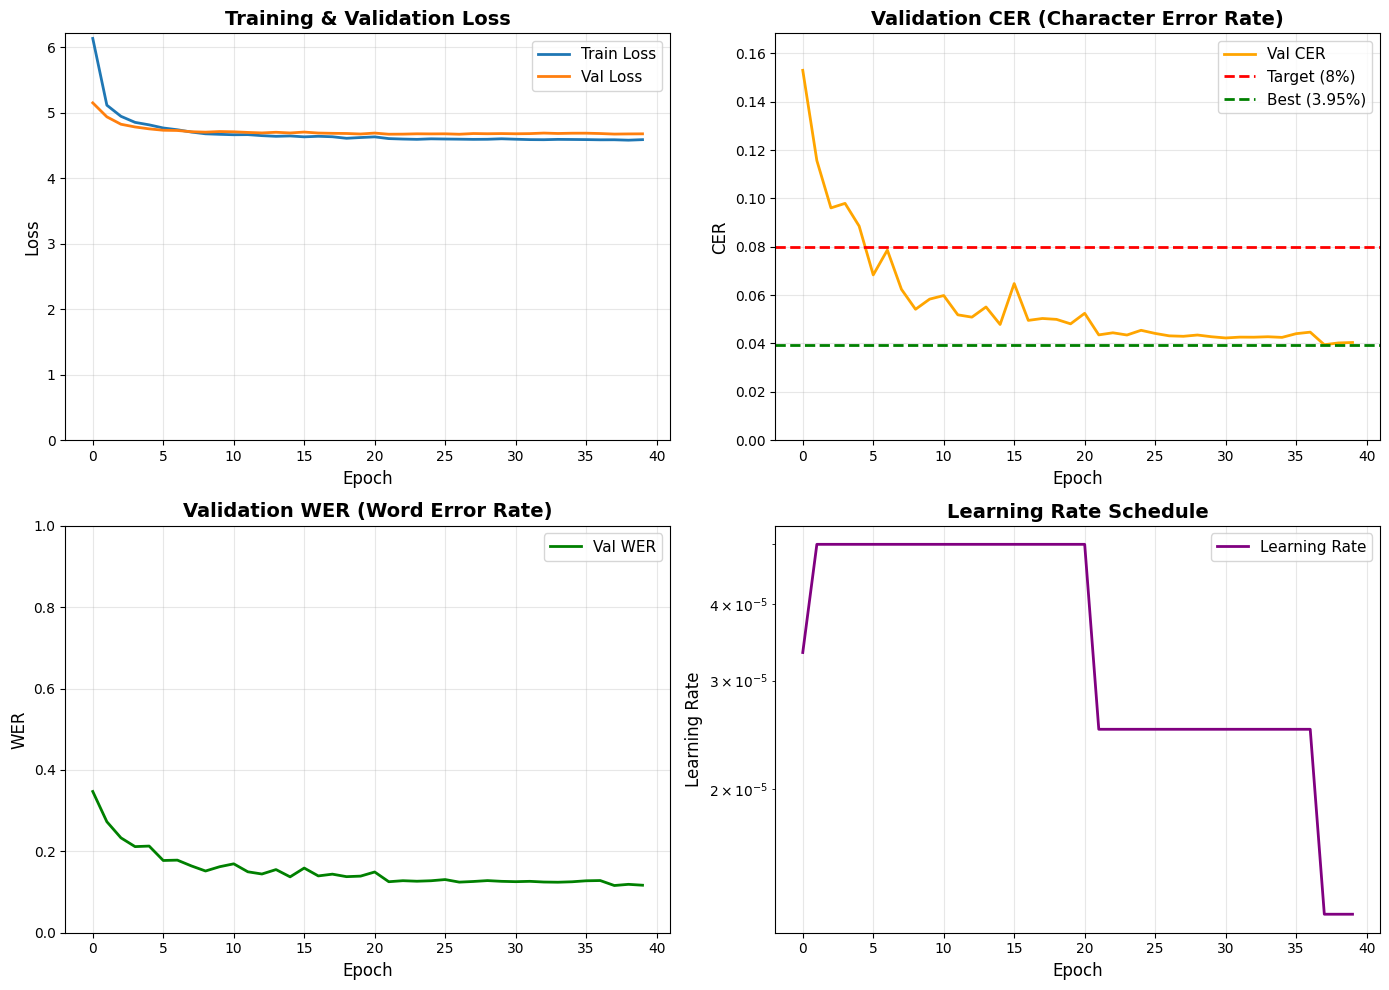


📊 TRAINING SUMMARY
Total Epochs: 40

📉 Loss:
   Final Train Loss: 4.5911
   Final Val Loss:   4.6800
   Best Val Loss:    4.6739 (Epoch 27)

📊 CER (Character Error Rate):
   Final Val CER: 0.0404 (96.0% acc)
   Best Val CER:  0.0395 (96.1% acc) ← SAVED MODEL
   Best Epoch:    38

📊 WER (Word Error Rate):
   Final Val WER: 0.1168
   Best Val WER:  0.1160 (Epoch 38)

🎯 Learning Rate:
   Initial LR:  3.33e-05
   Final LR:    1.25e-05

✅ Model saved at: '/kaggle/working/best_encoder_decoder.pth'
✅ Training curves saved at: '/kaggle/working/training_curves.png'


In [35]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Loss curves
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(bottom=0)

# Plot 2: CER curve
axes[0, 1].plot(history['val_cer'], label='Val CER', color='orange', linewidth=2)
axes[0, 1].axhline(y=0.08, color='red', linestyle='--', linewidth=2, label='Target (8%)')
axes[0, 1].axhline(y=best_val_cer, color='green', linestyle='--', linewidth=2, label=f'Best ({best_val_cer:.2%})')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('CER', fontsize=12)
axes[0, 1].set_title('Validation CER (Character Error Rate)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(bottom=0, top=min(1.0, max(history['val_cer']) * 1.1))

# Plot 3: WER curve
axes[1, 0].plot(history['val_wer'], label='Val WER', color='green', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('WER', fontsize=12)
axes[1, 0].set_title('Validation WER (Word Error Rate)', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(bottom=0, top=1.0)

# Plot 4: Learning Rate
axes[1, 1].plot(history['lr'], label='Learning Rate', color='purple', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Learning Rate', fontsize=12)
axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
print("✅ Saved training curves to '/kaggle/working/training_curves.png'")
plt.show()

# Print summary statistics
print(f"\n{'='*60}")
print("📊 TRAINING SUMMARY")
print(f"{'='*60}")
print(f"Total Epochs: {len(history['train_loss'])}")
print(f"\n📉 Loss:")
print(f"   Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"   Final Val Loss:   {history['val_loss'][-1]:.4f}")
print(f"   Best Val Loss:    {min(history['val_loss']):.4f} (Epoch {history['val_loss'].index(min(history['val_loss']))+1})")

print(f"\n📊 CER (Character Error Rate):")
print(f"   Final Val CER: {history['val_cer'][-1]:.4f} ({(1-history['val_cer'][-1])*100:.1f}% acc)")
print(f"   Best Val CER:  {best_val_cer:.4f} ({(1-best_val_cer)*100:.1f}% acc) ← SAVED MODEL")
print(f"   Best Epoch:    {history['val_cer'].index(best_val_cer)+1}")

print(f"\n📊 WER (Word Error Rate):")
print(f"   Final Val WER: {history['val_wer'][-1]:.4f}")
print(f"   Best Val WER:  {min(history['val_wer']):.4f} (Epoch {history['val_wer'].index(min(history['val_wer']))+1})")

print(f"\n🎯 Learning Rate:")
print(f"   Initial LR:  {history['lr'][0]:.2e}")
print(f"   Final LR:    {history['lr'][-1]:.2e}")

print(f"\n✅ Model saved at: '/kaggle/working/best_encoder_decoder.pth'")
print(f"✅ Training curves saved at: '/kaggle/working/training_curves.png'")
print('='*60)

## 🧪 8. Test & Visualize

✅ Loaded best model from epoch 38 with CER 0.0395


Testing on Val: 100%|██████████| 173/173 [00:19<00:00,  8.83it/s]



Test Results:
  📉 Test Loss: 4.6762
  📊 Test CER:  0.0395 (96.1% acc)
  📊 Test WER:  0.1160


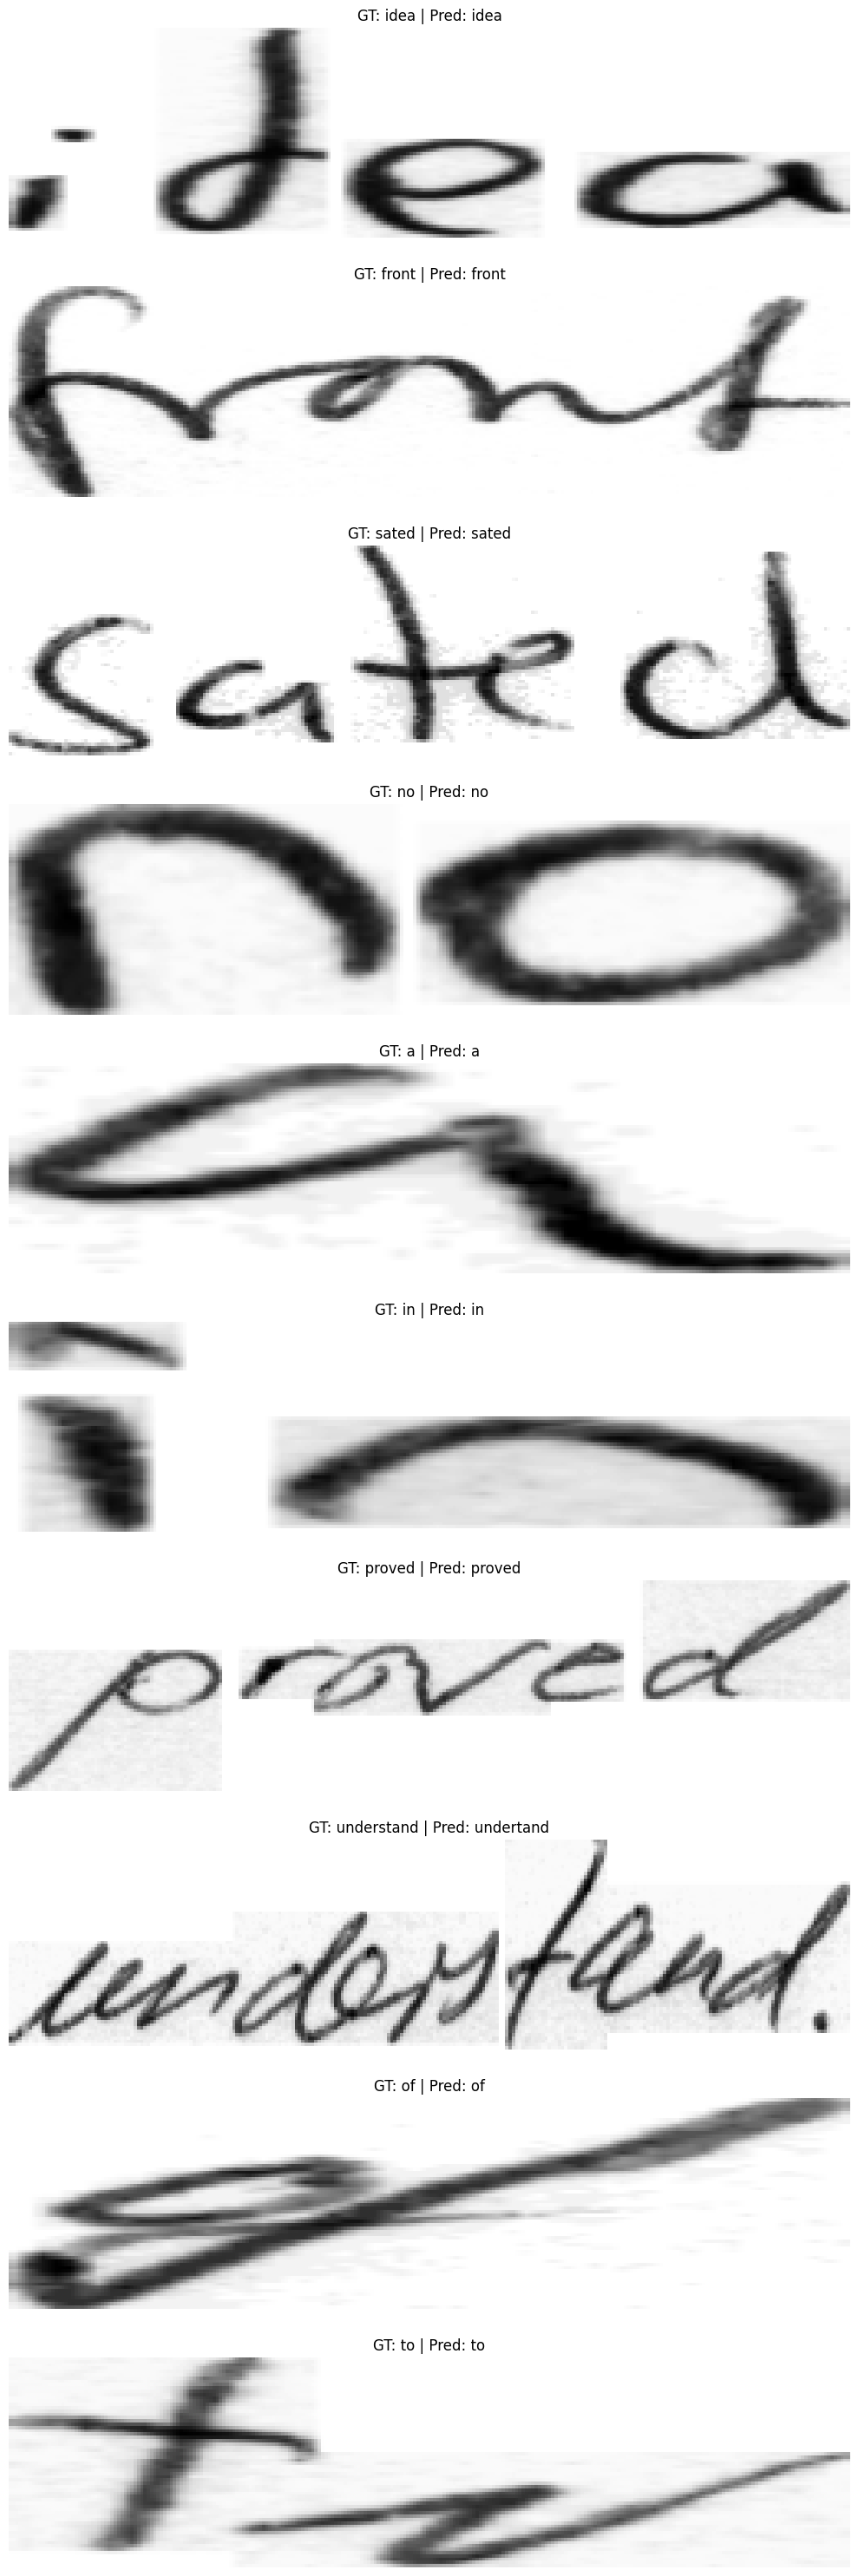

In [36]:
import random
import os

# Load best model
checkpoint_path = '/kaggle/working/best_encoder_decoder.pth'
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']} with CER {checkpoint['val_cer']:.4f}")

# Evaluate on validation set
model.eval()
val_loss = 0
all_predictions = []
all_targets = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Testing on Val"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Teacher forcing for loss
        tgt_input = labels[:, :-1]
        tgt_output = labels[:, 1:]
        seq_len = tgt_input.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(DEVICE)
        tgt_key_padding_mask = (tgt_input == PAD_IDX)
        
        logits = model(images, tgt_input, tgt_mask=tgt_mask,
                      tgt_key_padding_mask=tgt_key_padding_mask)
        loss = criterion(logits.reshape(-1, len(vocab)), tgt_output.reshape(-1))
        val_loss += loss.item()
        
        # Greedy decoding for metrics
        predictions = model.generate(images, SOS_IDX, EOS_IDX, max_len=50)
        all_predictions.extend(predictions)
        all_targets.extend(labels)

val_loss /= len(val_loader)
val_cer, val_wer = calculate_metrics(all_predictions, all_targets, idx_to_char)

print(f"\n{'='*60}")
print("Test Results:")
print(f"{'='*60}")
print(f"  📉 Test Loss: {val_loss:.4f}")
print(f"  📊 Test CER:  {val_cer:.4f} ({(1-val_cer)*100:.1f}% acc)")
print(f"  📊 Test WER:  {val_wer:.4f}")
print('='*60)

# Visualize 10 random samples
num_samples = 10
indices = random.sample(range(len(val_dataset)), num_samples)

fig, axes = plt.subplots(num_samples, 1, figsize=(10, 3*num_samples))
for i, idx in enumerate(indices):
    img, label = val_dataset[idx]
    img_tensor = img.unsqueeze(0).to(DEVICE)  # [1, 1, H, W]
    
    with torch.no_grad():
        pred = model.generate(img_tensor, SOS_IDX, EOS_IDX, max_len=50)[0]
    
    gt_text = decode_sequence(label, idx_to_char)
    pred_text = decode_sequence(pred, idx_to_char)
    
    # Plot image
    axes[i].imshow(img.squeeze(0).numpy(), cmap='gray')
    axes[i].set_title(f"GT: {gt_text} | Pred: {pred_text}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()